In [1]:
import sys
sys.path.append('../src')

import torch
from pathlib import Path
from tqdm import tqdm
from utils.get_data import get_dataset
import matplotlib.pyplot as plt
import numpy as np

torch.set_num_threads(5)

In [2]:
dataset_name = 'trackml-large'
dataset_dir = Path('../data/') / "tracking"
dataset = get_dataset(dataset_name, dataset_dir)

In [3]:
dataset[0]

Data(x=[66114, 15], edge_index=[2, 229066], y=[0], layer=[66114], particle_id=[66114], pt=[66114], reconstructable=[66114], sector=[66114], eta=[66114], n_hits=[66114], n_layers_hit=[66114], pos=[66114, 2], evtid=[1], s=[1], coords=[66114, 6])

In [4]:
num_good_pids = []
for data in tqdm(dataset):
    good_pids = data.particle_id[(data.pt > 0.9) & (data.reconstructable == 1)]
    unique_good_pids = torch.unique(good_pids)
    num_good_pids.append(unique_good_pids.shape[0])

100%|██████████| 1900/1900 [00:02<00:00, 775.26it/s]


(1928, 805, 1324.2284210526316)

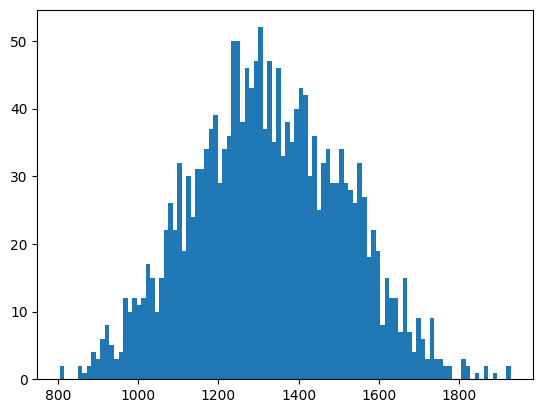

In [5]:
plt.hist(num_good_pids, bins=100)
max(num_good_pids), min(num_good_pids), np.mean(num_good_pids)

In [6]:
pt_thres = 0.9
num_queries = 1950
data_list = []
total_good_pid = []
for data in tqdm(dataset):
    try:
        del data.edge_index, data.y, data.sector, data.s
        del data.n_hits, data.n_layers_hit
        del data.point_pairs_index_rad, data.knn_edge_index_k60, data.point_pairs_index
    except AttributeError:
        # This is to handle the case where the attributes do not exist
        pass

    # extract unique particle_id and their pt
    pid_list = data.particle_id.unique()
    pt_list = []
    rec_list = []
    for pid in pid_list:
        if pid == 0:
            pt_list.append(-1)
            rec_list.append(-1)
            continue
        pt = data.pt[data.particle_id == pid]
        # assert all elements in pt are the same
        assert pt.shape[0] > 0, f"Particle ID {pid} has no pt values."
        assert (pt == pt[0]).all(), f"Particle ID {pid} has different pt values."
        # take the mean of pt
        pt_list.append(pt[0].item())
        rec_list.append(data.reconstructable[data.particle_id == pid][0].item())
    pt_list = torch.tensor(pt_list, dtype=torch.float32)
    rec_list = torch.tensor(rec_list, dtype=torch.float32)

    good_pid = pid_list[(pt_list > 0.9) & (rec_list == 1.0)]
    assert good_pid.shape[0] + 1 <= num_queries, f"Too many good particles: {good_pid.shape[0]} > {num_queries}"
    total_good_pid.append(len(good_pid))

    masks = []
    for pid in data.particle_id:
        mask = torch.zeros(len(good_pid))
        if pid in good_pid:
            mask = (pid == good_pid).long()
        else:
            pass
        masks.append(mask)
    masks = torch.stack(masks, dim=0).T.unsqueeze(-1)
    labels = torch.zeros(len(good_pid), dtype=torch.long)
    data.targets = [{"labels": labels, "masks": masks}]

    data_list.append(data)

print(f"Max good particles: {max(total_good_pid)}")
print(f"Number of queries: {num_queries}")

100%|██████████| 1900/1900 [1:17:29<00:00,  2.45s/it]

Max good particles: 1928
Number of queries: 1950


In [4]:
data, slices = dataset.collate(data_list)
torch.save((data, slices, dataset.idx_split), dataset.processed_paths[0])

In [5]:
data

Data(x=[2836833, 15], layer=[2836833], particle_id=[2836833], pt=[2836833], reconstructable=[2836833], pos=[2836833, 2], evtid=[50], coords=[2836833, 6], targets=[50])

In [6]:
data.targets[0][0]['labels'].shape, data.targets[0][0]['masks'].shape

(torch.Size([1693]), torch.Size([1693, 65401, 1]))